# From counting to attention: three miniature language models

Bengio et al. (2003) &rarr; Mikolov et al. (2013, CBOW) &rarr; Vaswani et al. (2017, one attention head),
each trained on the same six-sentence corpus.

**What this notebook shows.** Three ways of collapsing a context window into a single vector before the
softmax: *concatenate* (Bengio), *average* (CBOW), *attention-weighted average* (Transformer). The three
models differ in that one line and almost nothing else, so the effect of the pooling operator is visible
in isolation.

**What this notebook cannot show.** Generalization. There are 16 training examples and 11 word types,
and no held-out set exists at this scale. Every model below fits its training sample. Loss differences
across the three models are *not* evidence about architecture quality: the models are trained on two
different prediction tasks with different irreducible error, which we compute explicitly in §5.

**Reproducibility.** All randomness is seeded, and §7 reports how much of the resulting geometry survives
a change of seed.

## 0. Setup

In [1]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patheffects as pe
from sklearn.decomposition import PCA

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200,
    "font.size": 9.5, "axes.titlesize": 10.5, "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "legend.frameon": False, "figure.constrained_layout.use": True,
})

import textwrap

SAVE_FIGS = False          # set True to also write figs/<name>.pdf for the slides

def finish(fig, name, caption):
    "Attach a reading guide under the figure, optionally save, and show."
    width = min(120, int(fig.get_size_inches()[0] / 0.062))
    fig.supxlabel(textwrap.fill(caption, width), fontsize=8, color="0.3", ha="left", x=0.012)
    if SAVE_FIGS:
        from pathlib import Path
        Path("figs").mkdir(exist_ok=True)
        fig.savefig(f"figs/{name}.pdf", bbox_inches="tight")
    plt.show()

print(f"torch {torch.__version__}  |  seed {SEED}")

torch 2.13.0+cpu  |  seed 0


## 1. Corpus and vocabulary

Six sentences, chosen so that gender and royalty are the only two systematic contrasts in the data.

One detail that matters for reproducibility: the original `list(set(words))` is **not** deterministic
across interpreter sessions, because Python randomises string hashing per process (`PYTHONHASHSEED`).
Index $\to$ word maps then change between runs, and so do all figures. `sorted(set(...))` fixes it.

A second detail worth saying out loud in class: the corpus hard-codes "strong" with *man* and "wise"
with *woman*. Any gender structure recovered below was put there by construction. That is the whole
mechanism behind measured embedding bias (Bolukbasi et al. 2016; Caliskan et al. 2017) &mdash; the geometry
faithfully reproduces the co-occurrence statistics it was given.

In [2]:
corpus = [
    "he is a king",
    "she is a queen",
    "he is a strong man",
    "she is a wise woman",
    "the king is a man",
    "the queen is a woman",
]

words = " ".join(corpus).split()
vocab = sorted(set(words))                      # deterministic, unlike list(set(...))
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for w, i in word_to_idx.items()}
V = len(vocab)

# semantic groups, used only for colouring the figures
GROUP = {"he": "masc", "king": "masc", "man": "masc", "strong": "masc",
         "she": "fem",  "queen": "fem", "woman": "fem", "wise": "fem",
         "the": "func", "a": "func", "is": "func"}
COLOR = {"masc": "#1f4e79", "fem": "#a5322b", "func": "#8a8a8a"}

print(f"|V| = {V} types, {len(words)} tokens")
print(vocab)

|V| = 11 types, 28 tokens
['a', 'he', 'is', 'king', 'man', 'queen', 'she', 'strong', 'the', 'wise', 'woman']


## 2. Two supervision rules

| model | input | target |
|---|---|---|
| Bengio NNLM | $(w_{t-2}, w_{t-1})$ | $w_t$ |
| Transformer | $(w_{t-2}, w_{t-1})$ | $w_t$ |
| CBOW | $(w_{t-1}, w_{t+1})$ | $w_t$ |

CBOW solves a *different* problem: it sees the right context, which the causal models do not.
Keep this in mind before comparing losses across models.

In [3]:
def next_word_pairs(corpus, k=2):
    "Causal: predict w_t from the k preceding tokens."
    return [(toks[i-k:i], toks[i])
            for s in corpus for toks in [s.split()]
            for i in range(k, len(toks))]

def cbow_pairs(corpus):
    "Predict the centre token from one token on each side."
    return [([toks[i-1], toks[i+1]], toks[i])
            for s in corpus for toks in [s.split()]
            for i in range(1, len(toks)-1)]

def encode(pairs):
    X = torch.tensor([[word_to_idx[w] for w in ctx] for ctx, _ in pairs])
    y = torch.tensor([word_to_idx[t] for _, t in pairs])
    return X, y

causal_pairs, cbow_p = next_word_pairs(corpus), cbow_pairs(corpus)
X_causal, y_causal = encode(causal_pairs)
X_cbow,   y_cbow   = encode(cbow_p)

print(f"causal: {len(causal_pairs)} examples   cbow: {len(cbow_p)} examples")
pd.DataFrame({"context": [" ".join(c) for c, _ in causal_pairs],
              "target":  [t for _, t in causal_pairs]}).head(8)

causal: 16 examples   cbow: 16 examples


,context,target
0,he is,a
1,is a,king
2,she is,a
3,is a,queen
4,he is,a
5,is a,strong
6,a strong,man
7,she is,a


## 3. The three models

### 3.1 Bengio et al. (2003), NNLM

$$
h = \tanh\!\big(H\,[\,e(w_{t-2});\,e(w_{t-1})\,] + d\big),
\qquad
z = U h + b .
$$

The context vector is a **concatenation**, so the model is order-aware but the first hidden layer has
$(k\cdot m)\times h$ parameters that grow with the window. The original paper also carries a direct
term $Wx$ from the concatenated embeddings to the logits; it is included below as an option, off by
default. In 2003 the binding cost was the $|V| \times h$ output matrix &mdash; the reason the next decade
of work went into cheapening the softmax.

### 3.2 Word2Vec CBOW (Mikolov et al., 2013)

$$
\bar{e} = \tfrac{1}{|C|}\sum_{w\in C} e(w), \qquad z = W\bar{e} + b .
$$

**Averaging** discards order: `("he","a")` and `("a","he")` are the same input. What made word2vec fast
was not only removing the nonlinear hidden layer but also replacing the full softmax with negative
sampling or a hierarchical softmax. We use a full softmax over 11 types, so that part of the speedup is
invisible here &mdash; the model below is CBOW's *architecture*, not its training trick.

### 3.3 One Transformer block (Vaswani et al., 2017)

$$
X = E[w] + P[\text{pos}], \qquad
A = \mathrm{softmax}\!\Big(\tfrac{QK^{\top}}{\sqrt{d_k}} + M\Big), \qquad
Z = AV, \qquad z = W_o\, Z_{[\text{last}]} .
$$

Three points of precision for the lecture:

1. **Learned positions.** Vaswani et al. use fixed sinusoidal encodings; the embedding table below is the
   *learned* variant (as in GPT/BERT). Both are in the paper's ablation; they perform comparably.
2. **The $\sqrt{d_k}$ divisor** normalises the variance of the dot product, not its mean. With
   $q, k$ having i.i.d. coordinates of variance $\sigma^2$, $\operatorname{Var}(q^\top k)=d_k\sigma^4$, so
   without the divisor the softmax saturates as $d_k$ grows and gradients vanish. The code uses
   `K.size(-1)`, which is $d_k$; the original notebook used the model width, which coincides only in the
   single-head case.
3. **The causal mask** is a no-op for the prediction we read out (the last position attends to everything
   anyway). It is included because it is what makes the *all-positions* objective valid, i.e. why a
   Transformer gets $T$ training signals per sequence where the NNLM gets one.

Left out relative to a real block: multi-head attention, residual connections, LayerNorm, the
position-wise feed-forward network, and dropout. This is an attention *layer*, not a Transformer.

In [4]:
class BengioNNLM(nn.Module):
    def __init__(self, V, d=10, k=2, h=16, direct=False):
        super().__init__()
        self.embeddings = nn.Embedding(V, d)
        self.H = nn.Linear(k * d, h)
        self.U = nn.Linear(h, V)
        self.W = nn.Linear(k * d, V, bias=False) if direct else None

    def forward(self, idx):
        x = self.embeddings(idx).flatten(1)          # CONCATENATE
        z = self.U(torch.tanh(self.H(x)))
        return z + self.W(x) if self.W is not None else z


class CBOW(nn.Module):
    def __init__(self, V, d=10):
        super().__init__()
        self.embeddings = nn.Embedding(V, d)
        self.out = nn.Linear(d, V)

    def forward(self, idx):
        return self.out(self.embeddings(idx).mean(dim=1))   # AVERAGE


class MiniTransformer(nn.Module):
    def __init__(self, V, d=10, context=2, causal=True):
        super().__init__()
        self.embeddings = nn.Embedding(V, d)          # named as in the other two, for shared plotting
        self.pos = nn.Embedding(context, d)
        self.W_q = nn.Linear(d, d, bias=False)
        self.W_k = nn.Linear(d, d, bias=False)
        self.W_v = nn.Linear(d, d, bias=False)
        self.out = nn.Linear(d, V)
        self.causal = causal

    def forward(self, idx, return_attention=False):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device).expand(B, T)
        x = self.embeddings(idx) + self.pos(pos)
        Q, K, Val = self.W_q(x), self.W_k(x), self.W_v(x)
        scores = Q @ K.transpose(1, 2) / K.size(-1) ** 0.5          # divide by sqrt(d_k)
        if self.causal:
            mask = torch.triu(torch.ones(T, T, dtype=torch.bool, device=idx.device), 1)
            scores = scores.masked_fill(mask, float("-inf"))
        A = F.softmax(scores, dim=-1)
        z = self.out((A @ Val)[:, -1, :])                            # read out the last position
        return (z, A) if return_attention else z


def n_params(m):
    return sum(p.numel() for p in m.parameters())

torch.manual_seed(SEED); bengio = BengioNNLM(V)
torch.manual_seed(SEED); cbow = CBOW(V)
torch.manual_seed(SEED); tfm = MiniTransformer(V)

pd.DataFrame({"model": ["Bengio NNLM", "CBOW", "Mini-Transformer"],
              "parameters": [n_params(bengio), n_params(cbow), n_params(tfm)]})

,model,parameters
0,Bengio NNLM,633
1,CBOW,231
2,Mini-Transformer,551


## 4. Training

Full-batch Adam rather than the original one-example-at-a-time loop: with 16 examples the gradient is
exact, the run is deterministic, and the loss trace is a clean object to plot. The three models get an
identical budget and learning rate.

Read the accuracy column against the last one: $11/16 = 0.6875$ is the *highest attainable* training
accuracy on the causal task, not a shortfall. Section 5 says why.

In [5]:
def train(model, X, y, steps=1500, lr=0.01):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = np.empty(steps)
    for t in range(steps):
        opt.zero_grad()
        loss = F.cross_entropy(model(X), y)
        loss.backward(); opt.step()
        hist[t] = loss.item()
    return hist

hist = {
    "Bengio NNLM":      train(bengio, X_causal, y_causal),
    "CBOW":             train(cbow,   X_cbow,   y_cbow),
    "Mini-Transformer": train(tfm,    X_causal, y_causal),
}

def accuracy(model, X, y):
    with torch.no_grad():
        return (model(X).argmax(1) == y).float().mean().item()

def max_accuracy(pairs):
    "Ceiling implied by contexts that repeat with different targets (see section 5)."
    from collections import defaultdict, Counter
    tab = defaultdict(Counter)
    for ctx, tgt in pairs:
        tab[tuple(ctx)][tgt] += 1
    return sum(c.most_common(1)[0][1] for c in tab.values()) / len(pairs)

pd.DataFrame({
    "model": list(hist),
    "final loss (nats)": [h[-1] for h in hist.values()],
    "train accuracy": [accuracy(bengio, X_causal, y_causal),
                       accuracy(cbow, X_cbow, y_cbow),
                       accuracy(tfm, X_causal, y_causal)],
    "attainable maximum": [max_accuracy(causal_pairs), max_accuracy(cbow_p), max_accuracy(causal_pairs)],
}).round(4)

,model,final loss (nats),train accuracy,attainable maximum
0,Bengio NNLM,0.6720,0.6875,0.6875
1,CBOW,0.0869,0.9375,0.9375
2,Mini-Transformer,0.6719,0.6875,0.6875


## 5. Where the loss can and cannot go

The loss does not go to zero, and it should not. The context `("is","a")` occurs six times with six
*different* continuations (`king, queen, strong, wise, man, woman`). A model that predicts the empirical
conditional distribution perfectly still pays $\ln 6$ nats on each of those six examples. The floor is

$$
\mathcal{L}^{\star} \;=\; \frac{1}{N}\sum_{c} n_c \, \hat{H}(w \mid c),
$$

the empirical conditional entropy of the target given the context. It is the correct reference line for
these curves &mdash; and it differs between the two tasks, which is exactly why the Bengio/Transformer curves
cannot be compared against the CBOW curve.

uniform baseline      ln|V| = 2.398 nats
floor, causal task            = 0.672 nats  (= (6/16)*ln 6)
floor, CBOW task              = 0.087 nats  (= (2/16)*ln 2)


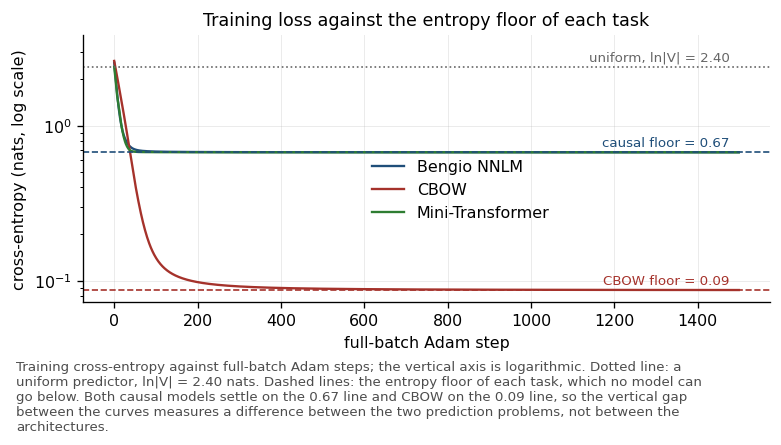

,model,final loss,floor,excess over floor
0,Bengio NNLM,0.672038,0.671910,0.000128
1,CBOW,0.086875,0.086643,0.000232
2,Mini-Transformer,0.671924,0.671910,0.000014


In [6]:
def entropy_floor(pairs):
    "Average empirical conditional entropy H(target | context), in nats."
    from collections import defaultdict, Counter
    tab = defaultdict(Counter)
    for ctx, tgt in pairs:
        tab[tuple(ctx)][tgt] += 1
    N = len(pairs)
    return sum(sum(c.values()) / N *
               -sum((n / sum(c.values())) * np.log(n / sum(c.values())) for n in c.values())
               for c in tab.values())

floor = {"causal": entropy_floor(causal_pairs), "cbow": entropy_floor(cbow_p)}
print(f"uniform baseline      ln|V| = {np.log(V):.3f} nats")
print(f"floor, causal task            = {floor['causal']:.3f} nats  (= (6/16)*ln 6)")
print(f"floor, CBOW task              = {floor['cbow']:.3f} nats  (= (2/16)*ln 2)")

fig, ax = plt.subplots(figsize=(6.4, 3.6))
for (name, h), c in zip(hist.items(), ["#1f4e79", "#a5322b", "#2e7d32"]):
    ax.plot(h, lw=1.4, color=c, label=name)
ax.axhline(np.log(V), ls=":", lw=1, color="0.4")
ax.axhline(floor["causal"], ls="--", lw=1, color="#1f4e79")
ax.axhline(floor["cbow"], ls="--", lw=1, color="#a5322b")
ax.set_yscale("log")
ax.set_xlabel("full-batch Adam step")
ax.set_ylabel("cross-entropy (nats, log scale)")
ax.set_title("Training loss against the entropy floor of each task")
ax.legend(loc="center", bbox_to_anchor=(0.55, 0.42))
for yv, txt, col in [(np.log(V), f"uniform, ln|V| = {np.log(V):.2f}", "0.4"),
                     (floor["causal"], f"causal floor = {floor['causal']:.2f}", "#1f4e79"),
                     (floor["cbow"], f"CBOW floor = {floor['cbow']:.2f}", "#a5322b")]:
    ax.text(len(h) * 0.985, yv * 1.10, txt, color=col, fontsize=8, ha="right")
ax.set_ylim(top=np.log(V) * 1.6)
finish(fig, "loss", (
    "Training cross-entropy against full-batch Adam steps; the vertical axis is logarithmic. Dotted line: a "
    "uniform predictor, ln|V| = 2.40 nats. Dashed lines: the entropy floor of each task, which no model can go "
    "below. Both causal models settle on the 0.67 line and CBOW on the 0.09 line, so the vertical gap between "
    "the curves measures a difference between the two prediction problems, not between the architectures."))

pd.DataFrame({"model": list(hist),
              "final loss": [h[-1] for h in hist.values()],
              "floor": [floor["causal"], floor["cbow"], floor["causal"]],
              "excess over floor": [hist["Bengio NNLM"][-1] - floor["causal"],
                                    hist["CBOW"][-1] - floor["cbow"],
                                    hist["Mini-Transformer"][-1] - floor["causal"]]}).round(6)

### 5.1 Did the model learn the *distribution*, or just the argmax?

If the causal models have converged to the empirical conditional, then $p(\cdot \mid \texttt{is},\texttt{a})$
should be close to uniform on the six observed continuations and near zero elsewhere. Predictive entropy
should sit near $\ln 6 = 1.792$. Accuracy alone cannot see this, which is why we look at the full
distribution.

In [7]:
def predictive(model, ctx):
    x = torch.tensor([[word_to_idx[w] for w in ctx]])
    with torch.no_grad():
        return F.softmax(model(x), dim=-1)[0].numpy()

ctx = ["is", "a"]
p_b, p_t = predictive(bengio, ctx), predictive(tfm, ctx)
tbl = (pd.DataFrame({"word": vocab, "Bengio": p_b, "Transformer": p_t})
         .sort_values("Bengio", ascending=False).head(8).round(3))
print(f"context = '{' '.join(ctx)}'   |   empirical: uniform on 6 words (1/6 = 0.167)")
print(f"predictive entropy   Bengio {-(p_b*np.log(p_b+1e-12)).sum():.3f}   "
      f"Transformer {-(p_t*np.log(p_t+1e-12)).sum():.3f}   target ln 6 = {np.log(6):.3f} nats")
tbl

context = 'is a'   |   empirical: uniform on 6 words (1/6 = 0.167)
predictive entropy   Bengio 1.793   Transformer 1.792   target ln 6 = 1.792 nats


,word,Bengio,Transformer
4,man,0.167,0.167
7,strong,0.167,0.167
3,king,0.167,0.167
5,queen,0.167,0.167
9,wise,0.167,0.167
10,woman,0.167,0.167
8,the,0.000,0.000
1,he,0.000,0.000


## 6. Embedding geometry &mdash; and how much of it is real

Two caveats before reading the scatter plots.

*The projection.* Eleven points in $\mathbb{R}^{10}$ projected to $\mathbb{R}^2$. PCA axes are defined only
up to sign and rotation, so **the panels are not comparable to each other**, and a distance that looks
large in the projection need not be large in $\mathbb{R}^{10}$. The share of variance retained is printed
on each axis; read it before reading the picture.

*The identification problem.* With $d = 10$ and $|V| = 11$, the embedding table has more free parameters
than the task constrains. Many geometries produce the same likelihood, so which one we land on is set by
the initialisation and by Adam's implicit bias as much as by the corpus. §7 quantifies how much survives
a reseed.

The cosine heatmap is the more honest object: it is invariant to rotation and to the choice of projection.

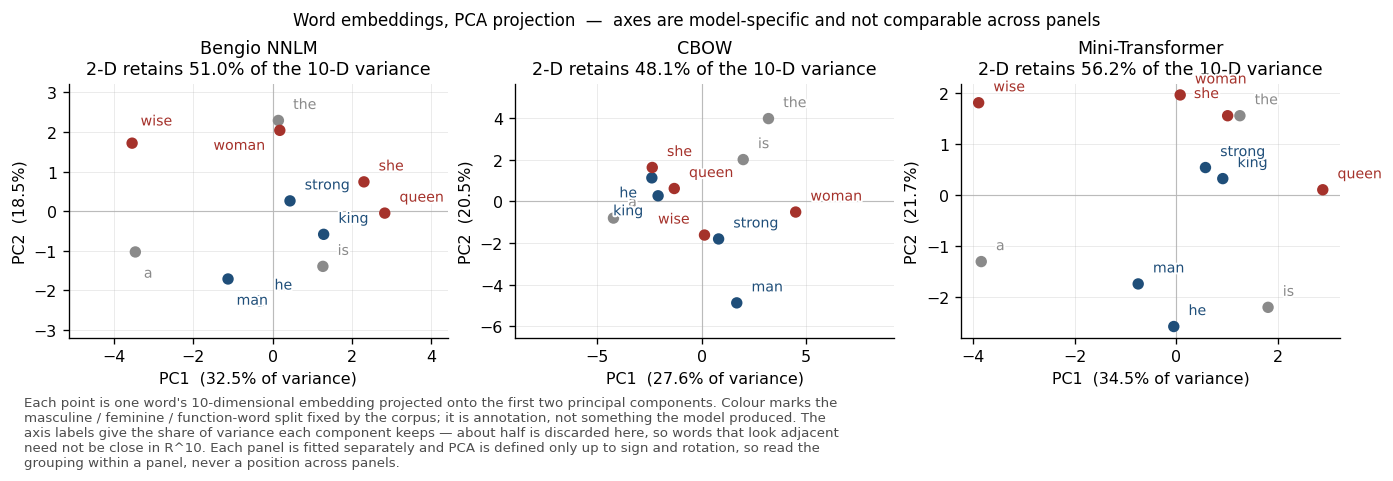

In [8]:
def emb_of(model):
    return model.embeddings.weight.detach().numpy()

def label_points(ax, Z, words, r=17.0):
    "Put each word label in the least crowded direction around its point."
    ax.figure.canvas.draw()                       # finalise the transform before measuring
    P = ax.transData.transform(Z)
    a = np.linspace(0, 2 * np.pi, 12, endpoint=False)
    dirs = np.stack([np.cos(a), np.sin(a)], axis=1)
    placed = []
    for i, w in enumerate(words):
        cand = P[i] + r * dirs
        obstacles = np.vstack([P] + ([np.array(placed)] if placed else []))
        room = np.linalg.norm(cand[:, None, :] - obstacles[None], axis=-1).min(axis=1)
        best = cand[int(room.argmax())]
        placed.append(best)
        o = (best - P[i]) * 72 / ax.figure.dpi     # display px -> typographic points
        ax.annotate(w, Z[i], textcoords="offset points", xytext=tuple(o),
                    ha="left" if o[0] > 1 else "right" if o[0] < -1 else "center",
                    va="bottom" if o[1] > 1 else "top" if o[1] < -1 else "center",
                    fontsize=8.5, color=COLOR[GROUP[w]], zorder=4,
                    path_effects=[pe.withStroke(linewidth=2.4, foreground="white")])

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.9))
for ax, (name, model) in zip(axes, [("Bengio NNLM", bengio), ("CBOW", cbow), ("Mini-Transformer", tfm)]):
    E = emb_of(model)
    pca = PCA(n_components=2).fit(E)
    Z, ev = pca.transform(E), pca.explained_variance_ratio_ * 100
    ax.scatter(Z[:, 0], Z[:, 1], s=34, zorder=3,
               color=[COLOR[GROUP[w]] for w in vocab])
    ax.axhline(0, lw=0.7, color="0.75", zorder=1); ax.axvline(0, lw=0.7, color="0.75", zorder=1)
    ax.set_xlabel(f"PC1  ({ev[0]:.1f}% of variance)")
    ax.set_ylabel(f"PC2  ({ev[1]:.1f}%)")
    ax.set_title(f"{name}\n2-D retains {ev.sum():.1f}% of the 10-D variance")
    ax.set_aspect("equal", adjustable="datalim"); ax.margins(0.26)
    label_points(ax, Z, vocab)
fig.suptitle("Word embeddings, PCA projection  —  axes are model-specific and not comparable across panels",
             fontsize=10)
finish(fig, "pca", (
    "Each point is one word's 10-dimensional embedding projected onto the first two principal components. Colour "
    "marks the masculine / feminine / function-word split fixed by the corpus; it is annotation, not something the "
    "model produced. The axis labels give the share of variance each component keeps — about half is discarded "
    "here, so words that look adjacent need not be close in R^10. Each panel is fitted separately and PCA is "
    "defined only up to sign and rotation, so read the grouping within a panel, never a position across panels."))

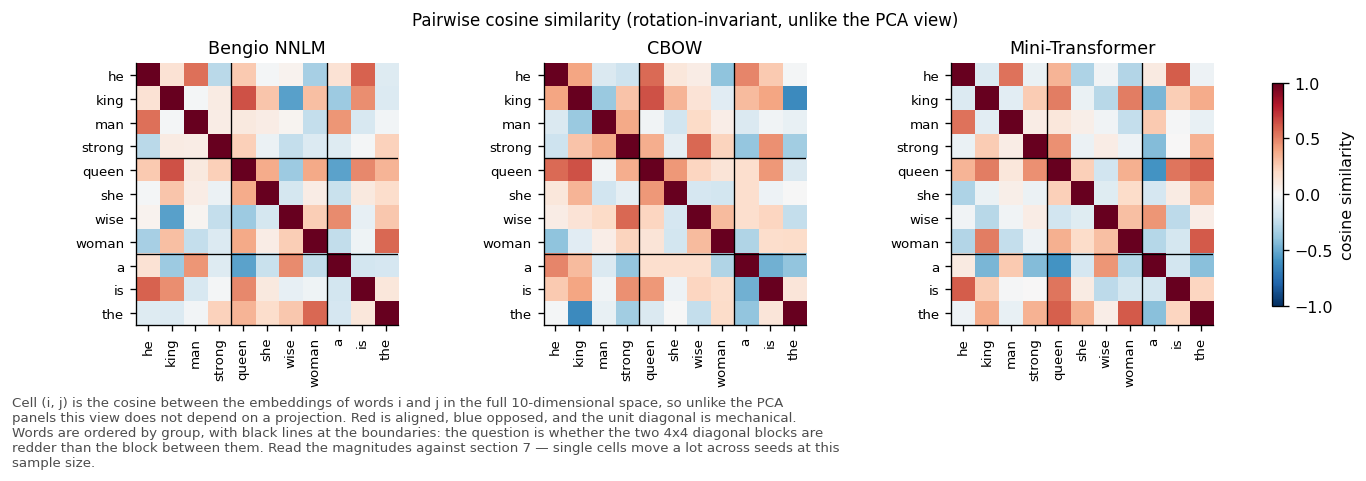

In [9]:
order = [w for g in ("masc", "fem", "func") for w in vocab if GROUP[w] == g]
perm = [word_to_idx[w] for w in order]

def cosines(E):
    E = E / np.linalg.norm(E, axis=1, keepdims=True)
    return (E @ E.T)[np.ix_(perm, perm)]

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.9))
for ax, (name, model) in zip(axes, [("Bengio NNLM", bengio), ("CBOW", cbow), ("Mini-Transformer", tfm)]):
    S = cosines(emb_of(model))
    im = ax.imshow(S, cmap="RdBu_r", norm=TwoSlopeNorm(0.0, -1, 1))
    ax.set_xticks(range(V), order, rotation=90, fontsize=8)
    ax.set_yticks(range(V), order, fontsize=8)
    ax.set_title(name); ax.grid(False)
    for s in (4, 8):                              # group boundaries: masc | fem | function words
        ax.axhline(s - .5, color="k", lw=.8); ax.axvline(s - .5, color="k", lw=.8)
fig.colorbar(im, ax=axes, shrink=0.85, label="cosine similarity")
fig.suptitle("Pairwise cosine similarity (rotation-invariant, unlike the PCA view)", fontsize=10)
finish(fig, "cosine", (
    "Cell (i, j) is the cosine between the embeddings of words i and j in the full 10-dimensional space, so unlike "
    "the PCA panels this view does not depend on a projection. Red is aligned, blue opposed, and the unit diagonal "
    "is mechanical. Words are ordered by group, with black lines at the boundaries: the question is whether the two "
    "4x4 diagonal blocks are redder than the block between them. Read the magnitudes against section 7 — single "
    "cells move a lot across seeds at this sample size."))

### 6.1 The analogy test

The corpus was built to invite $\textit{king} - \textit{man} + \textit{woman} \approx \textit{queen}$.
Two things are worth getting right when testing it:

- the standard 3CosAdd protocol **excludes the three query words** from the candidate set (Levy & Goldberg,
  2014); without that exclusion the nearest neighbour is almost always one of the inputs, and the test
  is vacuous;
- with 16 training examples the analogy is not expected to hold. Report the rank, not a cherry-picked hit.

In [10]:
def analogy(E, a, b, c, k=4, exclude=True):
    "b - a + c, ranked by cosine.  (man:king :: woman:?)"
    En = E / np.linalg.norm(E, axis=1, keepdims=True)
    v = En[word_to_idx[b]] - En[word_to_idx[a]] + En[word_to_idx[c]]
    sims = En @ (v / np.linalg.norm(v))
    if exclude:
        sims[[word_to_idx[w] for w in (a, b, c)]] = -np.inf
    rank = list(np.argsort(-sims))
    return [(idx_to_word[i], round(float(sims[i]), 3)) for i in rank[:k]], \
           rank.index(word_to_idx["queen"]) + 1

rows = []
for name, model in [("Bengio NNLM", bengio), ("CBOW", cbow), ("Mini-Transformer", tfm)]:
    top, r = analogy(emb_of(model), "man", "king", "woman")
    rows.append({"model": name, "top-4 for king - man + woman": top, "rank of 'queen'": r})
pd.DataFrame(rows)

,model,top-4 for king - man + woman,rank of 'queen'
0,Bengio NNLM,"[(queen, 0.452), (is, 0.286), (the, 0.229), (s...",1
1,CBOW,"[(queen, 0.435), (is, 0.331), (she, 0.192), (w...",1
2,Mini-Transformer,"[(the, 0.487), (queen, 0.35), (strong, 0.058),...",2


## 7. How much of this survives a change of seed?

The claim "the embedding learned gender" is testable. Refit each model under five seeds and look at the
dispersion of two cosines and of the analogy rank. If the spread swamps the signal, the geometry in §6 is
an artefact of one initialisation, and the honest statement in the lecture is that the *mechanism* is
being illustrated, not a *result*.

In [11]:
def fit(cls, X, y, seed, **kw):
    torch.manual_seed(seed)
    m = cls(V, **kw)
    train(m, X, y)
    return m

recs = []
for seed in range(5):
    for name, cls, X, y in [("Bengio NNLM", BengioNNLM, X_causal, y_causal),
                            ("CBOW", CBOW, X_cbow, y_cbow),
                            ("Mini-Transformer", MiniTransformer, X_causal, y_causal)]:
        E = emb_of(fit(cls, X, y, seed))
        En = E / np.linalg.norm(E, axis=1, keepdims=True)
        cos = lambda u, w: float(En[word_to_idx[u]] @ En[word_to_idx[w]])
        recs.append({"model": name, "seed": seed,
                     "cos(he,she)": cos("he", "she"),
                     "cos(king,queen)": cos("king", "queen"),
                     "rank of queen": analogy(E, "man", "king", "woman")[1]})

seed_df = pd.DataFrame(recs)
summary = seed_df.groupby("model")[["cos(he,she)", "cos(king,queen)", "rank of queen"]].agg(["mean", "std"])
summary.round(3)

cos(he,she)        cos(king,queen)        rank of queen  \
                        mean    std            mean    std          mean   
model                                                                      
Bengio NNLM            0.249  0.265           0.330  0.303           1.6   
CBOW                   0.519  0.247           0.676  0.138           1.4   
Mini-Transformer       0.055  0.337           0.304  0.341           2.4   

                         
                    std  
model                    
Bengio NNLM       1.342  
CBOW              0.894  
Mini-Transformer  1.673

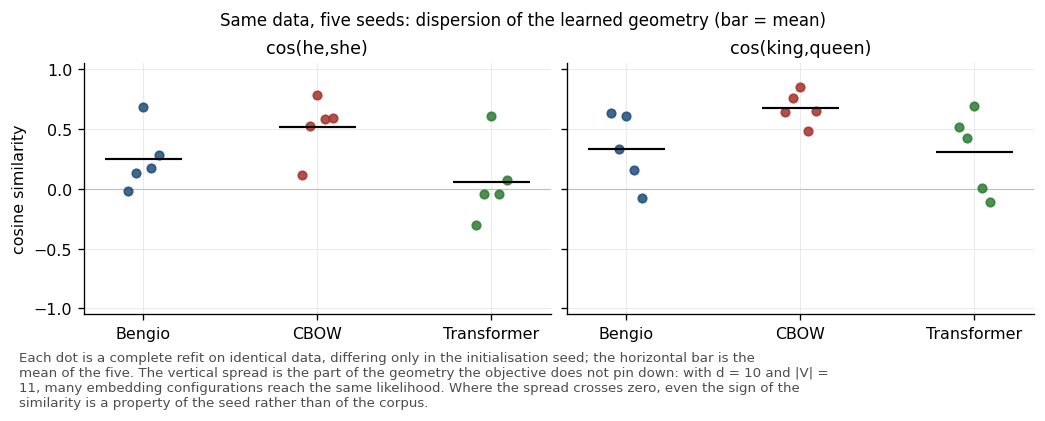

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4), sharey=True)
for ax, col in zip(axes, ["cos(he,she)", "cos(king,queen)"]):
    for i, (name, g) in enumerate(seed_df.groupby("model")):
        ax.scatter(np.full(len(g), i) + np.linspace(-.09, .09, len(g)), g[col],
                   s=26, color=["#1f4e79", "#a5322b", "#2e7d32"][i], alpha=.85, zorder=3)
        ax.hlines(g[col].mean(), i - .22, i + .22, color="k", lw=1.3, zorder=4)
    ax.set_xticks(range(3), ["Bengio", "CBOW", "Transformer"])
    ax.axhline(0, lw=.7, color="0.75")
    ax.set_ylim(-1.05, 1.05); ax.set_title(col)
axes[0].set_ylabel("cosine similarity")
fig.suptitle("Same data, five seeds: dispersion of the learned geometry (bar = mean)", fontsize=10)
finish(fig, "seeds", (
    "Each dot is a complete refit on identical data, differing only in the initialisation seed; the horizontal bar "
    "is the mean of the five. The vertical spread is the part of the geometry the objective does not pin down: with "
    "d = 10 and |V| = 11, many embedding configurations reach the same likelihood. Where the spread crosses zero, "
    "even the sign of the similarity is a property of the seed rather than of the corpus."))

## 8. Reading the attention weights

For each context we plot the attention row used for the prediction, i.e. the last query position over
the two key positions. With a two-token window this row has two entries that sum to one.

A caveat to state before anyone over-reads the heatmap: attention weights are **not** a feature-importance
measure, for two separate reasons.

*Values.* What reaches the softmax is $A V$ followed by $W_o$, so a low-weight position with a large value
vector can contribute more than a high-weight one.

*Queries.* The last token enters as the **query**. It therefore sets the entire weight distribution, whether
or not any weight lands on its own position. The two bottom rows below make this concrete: `a strong` puts
$0.999994$ of its mass on `a` and predicts *man*, while `a wise` puts $0.998$ on `wise` and predicts *woman*.
The token receiving $6	imes10^{-6}$ of the attention is the one that decided the answer. A near-zero weight
does not license the sentence "the model ignored that word."

Both directions of this argument have been made at length (Jain & Wallace, 2019; Wiegreffe & Pinter, 2019).
Here it bites harder still: one head, no feed-forward layer, 16 training points.

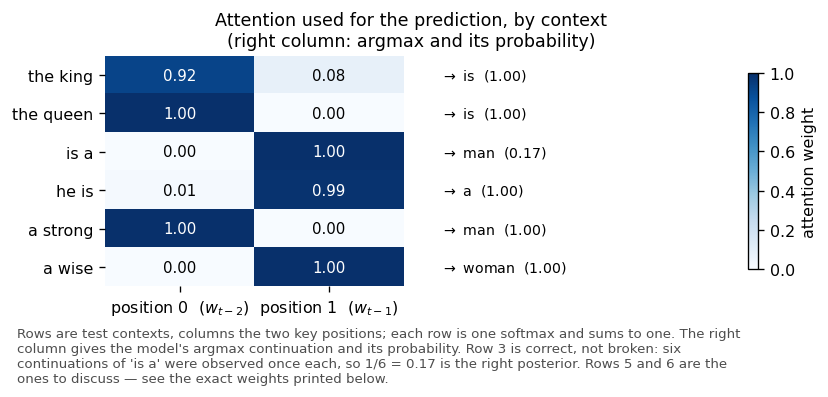

,context,w(position 0),w(position 1),prediction
0,the king,0.919848,0.080152,is
1,the queen,0.999682,0.000319,is
2,is a,0.000001,0.999999,man
3,he is,0.011796,0.988204,a
4,a strong,0.999994,0.000006,man
5,a wise,0.002104,0.997896,woman


In [13]:
tests = [["the", "king"], ["the", "queen"], ["is", "a"], ["he", "is"], ["a", "strong"], ["a", "wise"]]
Xt = torch.tensor([[word_to_idx[w] for w in c] for c in tests])
with torch.no_grad():
    logits, A = tfm(Xt, return_attention=True)
    probs = F.softmax(logits, dim=-1)
W = A[:, -1, :].numpy()                        # attention row used for the readout
pred = [idx_to_word[i] for i in probs.argmax(1).tolist()]
pmax = probs.max(1).values.numpy()

fig, ax = plt.subplots(figsize=(6.8, 3.2))
im = ax.imshow(W, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xlim(-0.5, 3.6)
ax.set_xticks([0, 1], [r"position 0  ($w_{t-2}$)", r"position 1  ($w_{t-1}$)"])
ax.set_yticks(range(len(tests)), [" ".join(c) for c in tests])
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        ax.text(j, i, f"{W[i, j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if W[i, j] > .55 else "black")
    ax.text(1.75, i, f"$\\to$ {pred[i]}  ({pmax[i]:.2f})", va="center", fontsize=8.5)
ax.set_title("Attention used for the prediction, by context\n(right column: argmax and its probability)")
ax.grid(False)
for sp in ax.spines.values():
    sp.set_visible(False)
fig.colorbar(im, ax=ax, shrink=.85, label="attention weight")
finish(fig, "attention", (
    "Rows are test contexts, columns the two key positions; each row is one softmax and sums to one. The right "
    "column gives the model's argmax continuation and its probability. Row 3 is correct, not broken: six "
    "continuations of 'is a' were observed once each, so 1/6 = 0.17 is the right posterior. Rows 5 and 6 are the "
    "ones to discuss — see the exact weights printed below."))

pd.DataFrame({"context": [" ".join(c) for c in tests],
              "w(position 0)": W[:, 0], "w(position 1)": W[:, 1],
              "prediction": pred}).round(6)

## 9. What to take away

1. The three architectures differ in **one line**: `flatten` / `mean` / `softmax(QK'/sqrt(d_k)) @ V`.
   Concatenation keeps order but scales badly with the window; averaging scales but discards order;
   attention keeps order (via positional embeddings) and lets the weights depend on the content.
2. Cross-entropy is bounded below by the empirical conditional entropy of the task. The Bengio/Transformer
   floor here is $0.67$ nats, the CBOW floor $0.09$ &mdash; the curves in §5 are not on a common scale.
3. Both models converge close to the empirical conditional distribution, not merely to the right argmax
   (§5.1). That is the stronger statement, and accuracy would not have revealed it.
4. The embedding geometry is **not identified** at this scale: §7 shows how much of it moves with the seed.
   The analogy story from the word2vec papers needs corpora of $10^8$&ndash;$10^9$ tokens, not 26.

Still missing, in order of importance for the next step: multi-head attention, residual + LayerNorm,
the position-wise FFN, subword tokenisation, negative sampling for CBOW, and any form of held-out
evaluation.

**References.** Bengio, Ducharme, Vincent & Jauvin (2003), *JMLR* 3:1137&ndash;1155 &middot;
Mikolov, Chen, Corrado & Dean (2013), arXiv:1301.3781 &middot;
Vaswani et al. (2017), *NeurIPS* &middot;
Levy & Goldberg (2014), *CoNLL* &middot;
Jain & Wallace (2019), *NAACL* &middot; Wiegreffe & Pinter (2019), *EMNLP*.